# Import Libraries

In [36]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv('/content/tcs_stock.csv')

In [38]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2015-01-01,TCS,EQ,2558.25,2567.0,2567.00,2541.00,2550.00,2545.55,2548.51,183415,4.674345e+13,8002,52870,0.2883
1,2015-01-02,TCS,EQ,2545.55,2551.0,2590.95,2550.60,2588.40,2579.45,2568.19,462870,1.188740e+14,27585,309350,0.6683
2,2015-01-05,TCS,EQ,2579.45,2581.0,2599.90,2524.65,2538.10,2540.25,2563.94,877121,2.248886e+14,43234,456728,0.5207
3,2015-01-06,TCS,EQ,2540.25,2529.1,2529.10,2440.00,2450.05,2446.60,2466.90,1211892,2.989615e+14,84503,714306,0.5894
4,2015-01-07,TCS,EQ,2446.60,2470.0,2479.15,2407.45,2426.90,2417.70,2433.96,1318166,3.208362e+14,101741,886368,0.6724


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                248 non-null    object 
 1   Symbol              248 non-null    object 
 2   Series              248 non-null    object 
 3   Prev Close          248 non-null    float64
 4   Open                248 non-null    float64
 5   High                248 non-null    float64
 6   Low                 248 non-null    float64
 7   Last                248 non-null    float64
 8   Close               248 non-null    float64
 9   VWAP                248 non-null    float64
 10  Volume              248 non-null    int64  
 11  Turnover            248 non-null    float64
 12  Trades              248 non-null    int64  
 13  Deliverable Volume  248 non-null    int64  
 14  %Deliverble         248 non-null    float64
dtypes: float64(9), int64(3), object(3)
memory usage: 29.2+ KB

In [40]:
df.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02,2.480000e+02,248.000000,2.480000e+02,248.000000
mean,2538.207460,2542.172782,2563.580444,2514.408468,2538.039718,2537.717944,2538.432137,1.172296e+06,2.977489e+14,66873.608871,7.960575e+05,0.670336
std,86.829359,87.605699,90.598368,82.952778,86.849305,87.057814,86.813053,6.220635e+05,1.576443e+14,28882.906787,4.309911e+05,0.090968
min,2319.800000,2319.400000,2343.900000,2315.250000,2321.000000,2319.800000,2322.270000,6.758200e+04,1.667550e+13,5197.000000,3.400300e+04,0.288300
25%,2495.312500,2499.500000,2518.900000,2472.100000,2497.500000,2495.150000,2496.665000,7.821352e+05,1.950716e+14,45476.250000,4.871065e+05,0.610850
50%,2543.050000,2548.500000,2566.000000,2520.000000,2540.150000,2541.475000,2540.445000,1.031024e+06,2.631783e+14,61449.500000,7.009530e+05,0.685600
75%,2592.000000,2594.250000,2615.750000,2567.300000,2593.425000,2592.000000,2592.607500,1.393266e+06,3.550390e+14,82066.750000,9.946628e+05,0.726050
max,2776.000000,2788.000000,2812.100000,2721.900000,2785.100000,2776.000000,2763.040000,4.834371e+06,1.206435e+15,211247.000000,2.989132e+06,0.890100


In [41]:
df.isnull().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


<Axes: >

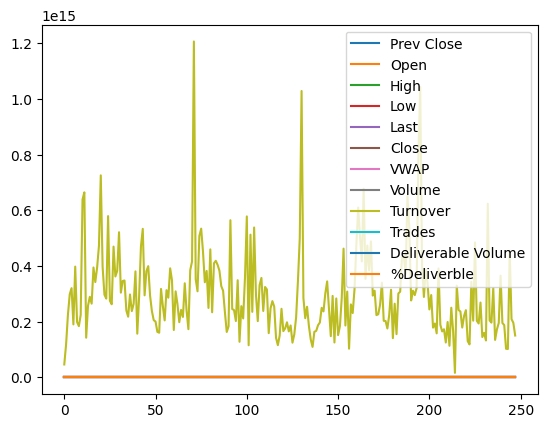

In [42]:
df.plot()

In [43]:
# Rename the 'Date' column to 'ds' and the 'Close' column to 'y'
df = df.rename(columns={'Date': 'ds', 'Close': 'y'})

# Select only the 'ds' and 'y' columns, as these are typically needed for Prophet
df = df[['ds', 'y']]

df.head()

,ds,y
0,2015-01-01,2545.55
1,2015-01-02,2579.45
2,2015-01-05,2540.25
3,2015-01-06,2446.60
4,2015-01-07,2417.70


In [44]:
df['ds'] = pd.to_datetime(df['ds'])
df.head()

,ds,y
0,2015-01-01,2545.55
1,2015-01-02,2579.45
2,2015-01-05,2540.25
3,2015-01-06,2446.60
4,2015-01-07,2417.70


In [45]:
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [46]:
# Initialize the Model
model=Prophet()
df.columns

Index(['ds', 'y'], dtype='object')

In [47]:
model.fit(df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [48]:
model.component_modes

{'additive': ['weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [49]:
df.head()

,ds,y
0,2015-01-01,2545.55
1,2015-01-02,2579.45
2,2015-01-05,2540.25
3,2015-01-06,2446.60
4,2015-01-07,2417.70


In [50]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)
future_dates.tail()

,ds
608,2016-12-26
609,2016-12-27
610,2016-12-28
611,2016-12-29
612,2016-12-30


In [51]:
prediction=model.predict(future_dates)
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01,2502.787135,2416.119009,2559.127793,2502.787135,2502.787135,-14.254588,-14.254588,-14.254588,-14.254588,-14.254588,-14.254588,0.0,0.0,0.0,2488.532546
1,2015-01-02,2504.873853,2407.482473,2561.648690,2504.873853,2504.873853,-18.921659,-18.921659,-18.921659,-18.921659,-18.921659,-18.921659,0.0,0.0,0.0,2485.952194
2,2015-01-05,2511.134009,2425.239557,2571.756245,2511.134009,2511.134009,-12.839871,-12.839871,-12.839871,-12.839871,-12.839871,-12.839871,0.0,0.0,0.0,2498.294138
3,2015-01-06,2513.220727,2426.473479,2571.464169,2513.220727,2513.220727,-17.749638,-17.749638,-17.749638,-17.749638,-17.749638,-17.749638,0.0,0.0,0.0,2495.471090
4,2015-01-07,2515.307446,2422.765263,2573.281208,2515.307446,2515.307446,-12.648392,-12.648392,-12.648392,-12.648392,-12.648392,-12.648392,0.0,0.0,0.0,2502.659054


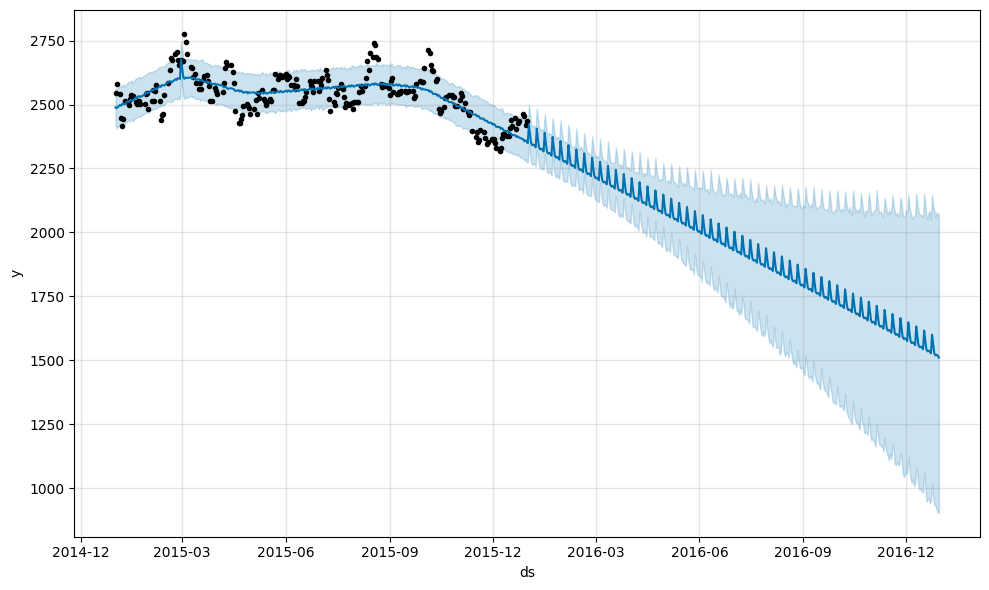

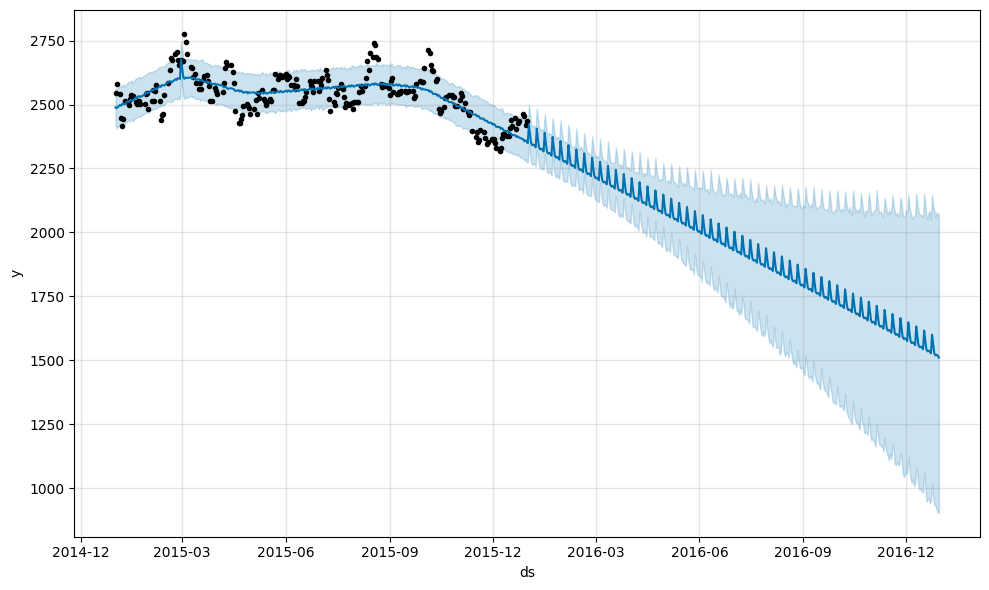

In [52]:
# plot the predicted projection
model.plot(prediction)

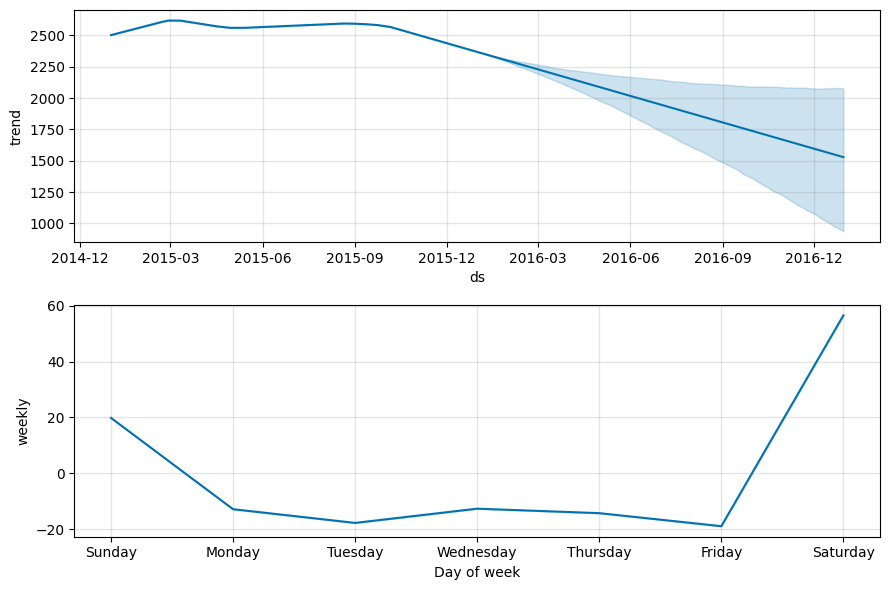

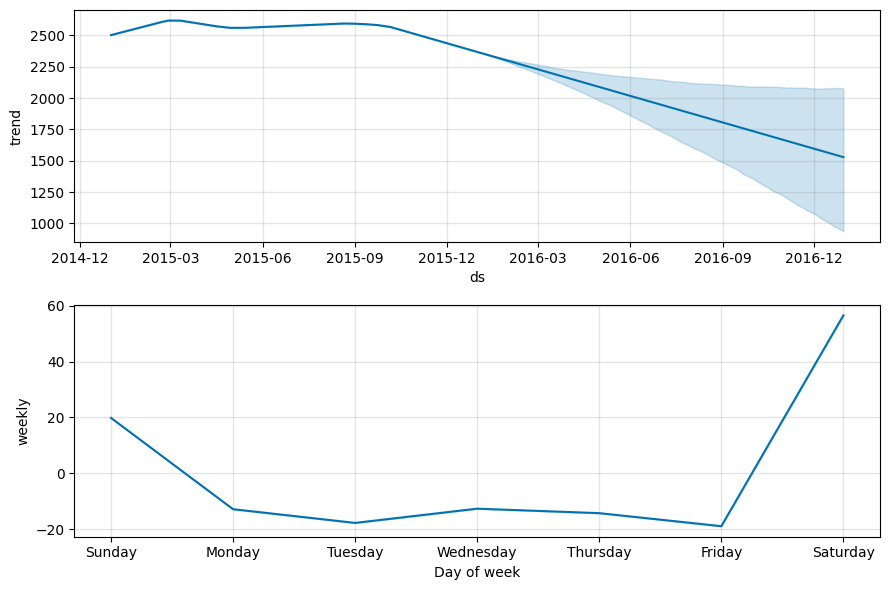

In [53]:
# Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [54]:
#Time Series Analysis

1960-1962
#Cross Validation
1960-61 #Train dataset
1961-62 #Test dataset
1962-63 #Validation

1899

In [55]:
df.head()

,ds,y
0,2015-01-01,2545.55
1,2015-01-02,2579.45
2,2015-01-05,2540.25
3,2015-01-06,2446.60
4,2015-01-07,2417.70


In [56]:
from prophet.diagnostics import cross_validation

# For example, use 6 months (180 days) for initial training, and 1 month (30 days) for period and horizon
df_cv = cross_validation(model, initial='180 days', period='30 days', horizon = '30 days')
df_cv.head()

INFO:prophet:Making 6 forecasts with cutoffs between 2015-07-04 00:00:00 and 2015-12-01 00:00:00


  0%|          | 0/6 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-07-06,2590.317358,2526.846746,2655.017147,2633.30,2015-07-04
1,2015-07-07,2581.423221,2515.242710,2648.307886,2616.25,2015-07-04
2,2015-07-08,2587.393158,2516.028801,2655.195203,2595.10,2015-07-04
3,2015-07-09,2592.679066,2527.545134,2658.667610,2522.50,2015-07-04
4,2015-07-10,2595.663645,2526.236078,2663.952284,2474.35,2015-07-04


In [57]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,2716.569282,52.120718,41.785009,0.016418,0.014817,0.016476,0.916667
1,4 days,3975.948381,63.055122,51.454068,0.019967,0.017013,0.020101,0.833333
2,5 days,4471.788653,66.871434,58.206328,0.022563,0.025320,0.022645,0.766667
3,6 days,4955.783371,70.397325,63.163877,0.024876,0.025338,0.024746,0.750000
4,7 days,4199.054343,64.800111,61.277087,0.024397,0.024244,0.024191,0.833333


In [58]:
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,2716.569282,52.120718,41.785009,0.016418,0.014817,0.016476,0.916667
1,4 days,3975.948381,63.055122,51.454068,0.019967,0.017013,0.020101,0.833333
2,5 days,4471.788653,66.871434,58.206328,0.022563,0.025320,0.022645,0.766667
3,6 days,4955.783371,70.397325,63.163877,0.024876,0.025338,0.024746,0.750000
4,7 days,4199.054343,64.800111,61.277087,0.024397,0.024244,0.024191,0.833333


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


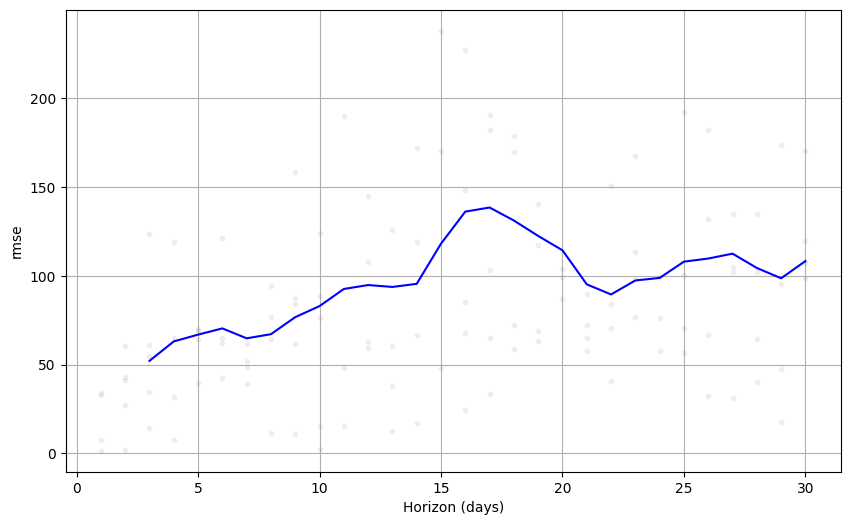

In [59]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

# Final Outcome of the Notebook

## Load TCS time series dataset

## Clean and prepares dataset

## Train Prophet forecasting model

## Predicts future passenger

##  Visualizes trend and seasonality

## Evaluates model accuracy using cross-validation and RMSE